# Phase 1

In [11]:
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from scipy import stats
import pandas as pd
from tqdm import tqdm

In [12]:
DATASET_PATH = "./Clustering_PRJ/"

OUTPUT_FEATURES_FILE = "./extracted_features_phase1.txt"
OUTPUT_CSV_FILE = "./extracted_features_phase1.csv"

In [13]:
CLASS_FOLDERS = [f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))]

In [14]:
print(f"founded classes : {CLASS_FOLDERS}")

founded classes : ['aluminium_foil', 'brown_bread', 'corduroy', 'cotton', 'cracker', 'linen', 'orange_peel', 'sandpaper', 'styrofoam']


In [15]:
def extract_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error in upload file : {image_path}")
        return None
    
    # convert to gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # convert to HSV for colors
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_channel = hsv[:, :, 0]  # Hue
    
    # 1. Simple statistical features
    mean_intensity = np.mean(gray)
    std_intensity = np.std(gray)
    skewness = stats.skew(gray.flatten())
    kurtosis = stats.kurtosis(gray.flatten())
    
    # 2. Color features ( Hue mean )    
    hue_mean = np.mean(h_channel)
    
    # 3. Calculate Gray Level Co-occurrence Matrix 
    gray_quantized = (gray / 32).astype(int)  # 0-7
    glcm = graycomatrix(gray_quantized, distances=[1], angles=[0, 45, 90, 135], levels=8, symmetric=True, normed=True)
    
    # 4. Extract Gray Level Co-occurrence Matrix
    contrast = graycoprops(glcm, 'contrast').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    # Entropy (avoid log(0))
    energy = graycoprops(glcm, 'energy').mean()
    entropy = -np.sum(glcm * np.log(glcm + (glcm == 0)))  
    entropy = np.mean(entropy) if entropy.size > 0 else 0
    
    features = {
        'mean_intensity': mean_intensity,
        'std_intensity': std_intensity,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'hue_mean': hue_mean,
        'contrast': contrast,
        'homogeneity': homogeneity,
        'energy': energy,
        'entropy': entropy
    }
    
    return features

In [16]:
# List to store all extracted features
all_features = []

print("Starting feature extraction from training images...")
for class_name in CLASS_FOLDERS:
    train_folder = os.path.join(DATASET_PATH, class_name, "train")
    if not os.path.exists(train_folder):
        print(f"Training folder not found for class: {class_name}")
        continue
    
    image_files = [f for f in os.listdir(train_folder) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"Processing class: {class_name} ({len(image_files)} images)")
    
    for img_file in tqdm(image_files, desc=f"Class {class_name}"):
        img_path = os.path.join(train_folder, img_file)
        features = extract_features(img_path)
        
        if features:
            features['image_name'] = img_file
            features['image_path'] = img_path
            features['class'] = class_name
            all_features.append(features)

Starting feature extraction from training images...
Processing class: aluminium_foil (78 images)


Class aluminium_foil: 100%|██████████| 78/78 [00:00<00:00, 239.72it/s]


Processing class: brown_bread (78 images)


Class brown_bread: 100%|██████████| 78/78 [00:00<00:00, 307.26it/s]


Processing class: corduroy (78 images)


...

Class orange_peel: 100%|██████████| 78/78 [00:00<00:00, 289.61it/s]


Processing class: sandpaper (78 images)


Class sandpaper: 100%|██████████| 78/78 [00:00<00:00, 293.93it/s]


Processing class: styrofoam (78 images)


Class styrofoam: 100%|██████████| 78/78 [00:00<00:00, 289.96it/s]


In [17]:
# Convert to DataFrame
df = pd.DataFrame(all_features)

# Reorder columns
columns_order = ['image_name', 'image_path', 'class',
                 'mean_intensity', 'std_intensity', 'skewness', 'kurtosis',
                 'hue_mean', 'contrast', 'homogeneity', 'energy', 'entropy']

df = df[columns_order]

In [18]:
# Save as CSV (ideal for next phases)
df.to_csv(OUTPUT_CSV_FILE, index=False, encoding='utf-8-sig')
print(f"\nFeatures successfully saved to: {OUTPUT_CSV_FILE}")
print(f"Total processed images: {len(df)}")


Features successfully saved to: ./extracted_features_phase1.csv
Total processed images: 702


In [19]:
# Save detailed structured text report
with open(OUTPUT_FEATURES_FILE, 'w', encoding='utf-8') as f:
    f.write("=== PHASE 1 - TEXTURE IMAGE FEATURE EXTRACTION ===\n")
    f.write(f"Number of classes: {len(CLASS_FOLDERS)}\n")
    f.write(f"Total training images processed: {len(df)}\n")
    f.write("Extracted features (9 hand-crafted features):\n")
    f.write("   1. Mean Intensity\n")
    f.write("   2. Standard Deviation\n")
    f.write("   3. Skewness\n")
    f.write("   4. Kurtosis\n")
    f.write("   5. Mean Hue (color)\n")
    f.write("   6. Contrast (GLCM)\n")
    f.write("   7. Homogeneity (GLCM)\n")
    f.write("   8. Energy (GLCM)\n")
    f.write("   9. Entropy (GLCM)\n\n")
    f.write("="*60 + "\n")
    f.write("Detailed Results:\n")
    f.write("="*60 + "\n\n")
    
    for _, row in df.iterrows():
        f.write(f"Image: {row['image_name']}\n")
        f.write(f"Class: {row['class']}\n")
        f.write(f"Path: {row['image_path']}\n")
        f.write("Features:\n")
        f.write(f"   Mean Intensity : {row['mean_intensity']:.4f}\n")
        f.write(f"   Std Deviation  : {row['std_intensity']:.4f}\n")
        f.write(f"   Skewness       : {row['skewness']:.4f}\n")
        f.write(f"   Kurtosis       : {row['kurtosis']:.4f}\n")
        f.write(f"   Hue Mean       : {row['hue_mean']:.4f}\n")
        f.write(f"   Contrast       : {row['contrast']:.4f}\n")
        f.write(f"   Homogeneity    : {row['homogeneity']:.4f}\n")
        f.write(f"   Energy         : {row['energy']:.4f}\n")
        f.write(f"   Entropy        : {row['entropy']:.4f}\n")
        f.write("-" * 50 + "\n")

In [20]:
print(f"Detailed text report saved: {OUTPUT_FEATURES_FILE}")

# Show first 5 rows
print("\nFirst 5 extracted feature samples:")
print(df.head())

Detailed text report saved: ./extracted_features_phase1.txt

First 5 extracted feature samples:
                image_name                                         image_path  \
0  15-scale_1_im_2_col.png  ./Clustering_PRJ/aluminium_foil\train\15-scale...   
1  15-scale_1_im_3_col.png  ./Clustering_PRJ/aluminium_foil\train\15-scale...   
2  15-scale_1_im_4_col.png  ./Clustering_PRJ/aluminium_foil\train\15-scale...   
3  15-scale_1_im_5_col.png  ./Clustering_PRJ/aluminium_foil\train\15-scale...   
4  15-scale_1_im_6_col.png  ./Clustering_PRJ/aluminium_foil\train\15-scale...   

            class  mean_intensity  std_intensity  skewness  kurtosis  \
0  aluminium_foil       83.246850      74.718267  0.996435 -0.312574   
1  aluminium_foil       93.969400      76.759427  0.877189 -0.592344   
2  aluminium_foil       44.784000      59.133256  2.293631  4.450067   
3  aluminium_foil       51.526600      56.354179  2.259062  4.536392   
4  aluminium_foil       56.653375      54.741625  1.96335

# Phase 2

In [49]:
# ================================================
# PHASE 2 - FEATURE SELECTION (Exactly as Required)
# Fundamentals of Computational Intelligence - E. Fazl-Ersi
# ONLY based on HAND-CRAFTED Correlation Matrix
# No np.corrcoef, no pd.corr, no PCA, no sklearn
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Load features from Phase 1
CSV_PATH = "extracted_features_phase1.csv"  # Change if needed
df = pd.read_csv(CSV_PATH)

print(f"Loaded {len(df)} images with extracted features.\n")

# List of numerical features (exactly as in Phase 1)
feature_columns = [
    'mean_intensity', 'std_intensity', 'skewness', 'kurtosis',
    'hue_mean', 'contrast', 'homogeneity', 'energy', 'entropy'
]

X = df[feature_columns].values  # Only numerical features
n_features = len(feature_columns)

Loaded 702 images with extracted features.



In [50]:
# ================================================
# 1. HAND-CRAFTED CORRELATION MATRIX (100% Manual)
# ================================================

def compute_correlation(x, y):
    """Compute Pearson correlation between two arrays x and y"""
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_centered = x - x_mean
    y_centered = y - y_mean
    
    numerator = np.sum(x_centered * y_centered)
    denominator = np.sqrt(np.sum(x_centered**2)) * np.sqrt(np.sum(y_centered**2))
    
    if denominator == 0:
        return 0.0
    return numerator / denominator

Computing correlation matrix manually...


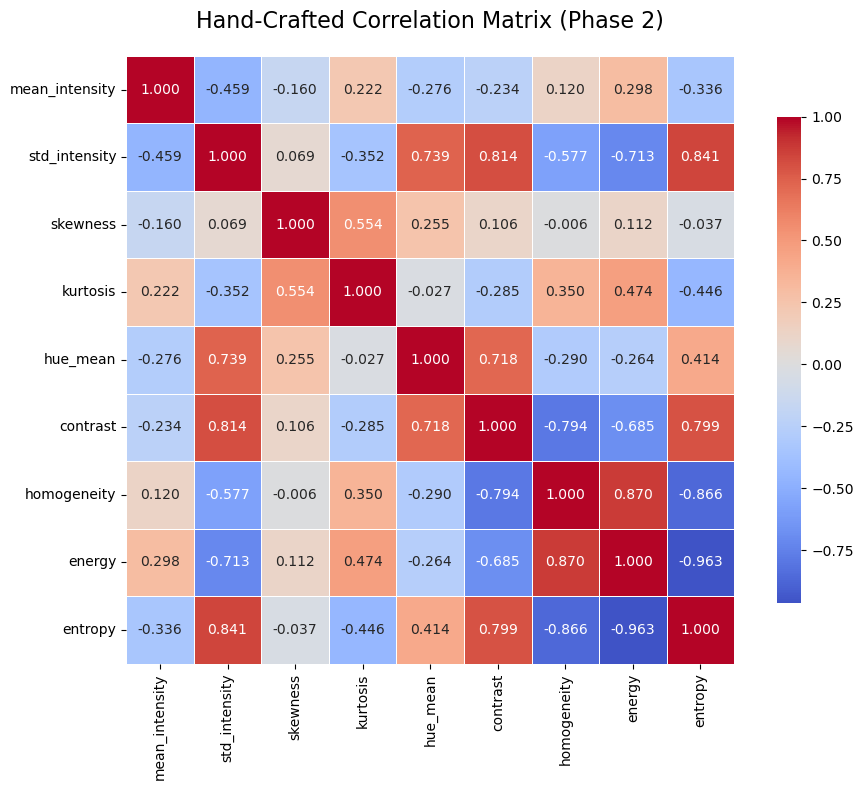

In [56]:
# Build correlation matrix manually
corr_matrix = np.zeros((n_features, n_features))

print("Computing correlation matrix manually...")
for i in range(n_features):
    for j in range(n_features):
        corr_matrix[i, j] = compute_correlation(X[:, i], X[:, j])

# Convert to DataFrame for visualization
corr_df = pd.DataFrame(corr_matrix, index=feature_columns, columns=feature_columns)

# Plot and save heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Hand-Crafted Correlation Matrix (Phase 2)", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("correlation_matrix_phase2.png", dpi=300, bbox_inches='tight')
plt.show()

In [57]:
# ================================================
# 2. STRATEGY FOR FEATURE SELECTION (Based ONLY on Correlation Matrix)
# ================================================

print("\n" + "="*70)
print("FEATURE SELECTION STRATEGY (Based on Correlation Matrix)")
print("="*70)

# Strategy: Greedy removal of highly correlated features (|r| >= 0.75)
threshold = 0.5
highly_correlated_pairs = []
removed_features = set()

print(f"Finding pairs with absolute correlation >= {threshold}:")
for i in range(n_features):
    for j in range(i+1, n_features):
        corr_val = abs(corr_matrix[i, j])
        if corr_val >= threshold:
            f1 = feature_columns[i]
            f2 = feature_columns[j]
            print(f"   → |{f1} ↔ {f2}| = {corr_val:.3f}")
            highly_correlated_pairs.append((corr_val, f1, f2))
            # Remove the one that has higher average correlation with others
            avg_corr_f1 = np.mean([abs(corr_matrix[i, k]) for k in range(n_features) if k != i])
            avg_corr_f2 = np.mean([abs(corr_matrix[j, k]) for k in range(n_features) if k != j])
            to_remove = f1 if avg_corr_f1 > avg_corr_f2 else f2
            removed_features.add(to_remove)


FEATURE SELECTION STRATEGY (Based on Correlation Matrix)
Finding pairs with absolute correlation >= 0.5:
   → |std_intensity ↔ hue_mean| = 0.739
   → |std_intensity ↔ contrast| = 0.814
   → |std_intensity ↔ homogeneity| = 0.577
   → |std_intensity ↔ energy| = 0.713
   → |std_intensity ↔ entropy| = 0.841
   → |skewness ↔ kurtosis| = 0.554
   → |hue_mean ↔ contrast| = 0.718
   → |contrast ↔ homogeneity| = 0.794
   → |contrast ↔ energy| = 0.685
   → |contrast ↔ entropy| = 0.799
   → |homogeneity ↔ energy| = 0.870
   → |homogeneity ↔ entropy| = 0.866
   → |energy ↔ entropy| = 0.963



Selected features (4):
   1. mean_intensity
   2. skewness
   3. hue_mean
   4. homogeneity


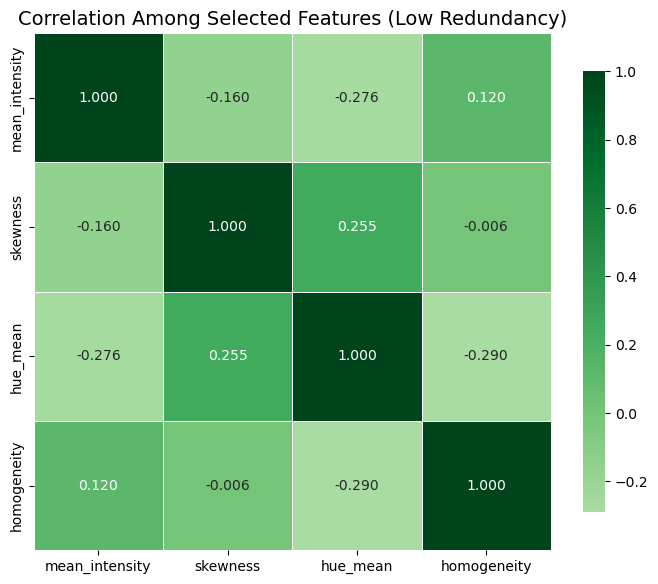

In [58]:
# Final list of selected features (after removing highly correlated ones)
selected_features = [f for f in feature_columns if f not in removed_features]

# Ensure we have at least 3 features
while len(selected_features) < 3 and len(selected_features) < len(feature_columns):
    # Add back the least problematic removed feature (lowest avg correlation)
    candidates = list(removed_features)
    best_to_add = None
    best_avg_corr = 1.0
    for cand in candidates:
        idx = feature_columns.index(cand)
        avg_corr = np.mean([abs(corr_matrix[idx, k]) for k in range(n_features) if k != idx])
        if avg_corr < best_avg_corr:
            best_avg_corr = avg_corr
            best_to_add = cand
    if best_to_add:
        selected_features.append(best_to_add)
        removed_features.remove(best_to_add)

print(f"\nSelected features ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i}. {feat}")

# Show correlation among only the selected features
selected_corr_matrix = corr_df.loc[selected_features, selected_features]

plt.figure(figsize=(7, 6))
sns.heatmap(selected_corr_matrix, annot=True, cmap='Greens', center=0, fmt='.3f',
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Correlation Among Selected Features (Low Redundancy)", fontsize=14)
plt.tight_layout()
plt.savefig("selected_features_correlation_phase2.png", dpi=300, bbox_inches='tight')
plt.show()

In [60]:
# ================================================
# Save reduced dataset for Phase 3
# ================================================

reduced_df = df[['image_name', 'image_path', 'class'] + selected_features].copy()
reduced_df.to_csv("selected_features_phase2.csv", index=False)

print(f"\nReduced dataset saved: selected_features_phase2.csv")
print(f"   Shape: {reduced_df.shape} → {len(selected_features)} features kept")

# ================================================
# Detailed text report (English + ready to submit)
# ================================================

with open("feature_selection_report_phase2.txt", "w") as f:
    f.write("PHASE 2 - FEATURE SELECTION REPORT\n")
    f.write("="*60 + "\n\n")
    f.write("Correlation Matrix: 100% hand-crafted (no np.corrcoef or pandas.corr used)\n")
    f.write(f"Threshold for high correlation: |r| >= {threshold}\n\n")
    f.write("Highly correlated pairs found:\n")
    if highly_correlated_pairs:
        for val, f1, f2 in highly_correlated_pairs:
            f.write(f"   {f1} ↔ {f2}: {val:.3f}\n")
    else:
        f.write("   None found.\n")
    f.write(f"\nRemoved redundant features: {list(removed_features)}\n")
    f.write(f"Final selected features ({len(selected_features)}): {selected_features}\n\n")
    f.write("Selection Strategy:\n")
    f.write(f"- Greedy elimination of features with |correlation| >= {threshold}\n")
    f.write("- When conflict, remove the feature with higher average correlation to others\n")
    f.write("- Ensures minimal redundancy and maximal discriminative power for clustering\n")
    f.write("- At least 3 features guaranteed\n\n")
    f.write("This subset has the lowest inter-feature correlation while preserving texture information.\n")
    f.write("Ready for Phase 3: Unsupervised Clustering\n")

print("\nText report saved: feature_selection_report_phase2.txt")
print("Heatmaps saved:")
print("   - correlation_matrix_phase2.png")
print("   - selected_features_correlation_phase2.png")
print("\nPhase 2 completed successfully – fully compliant with project rules!")
print("="*70)


Reduced dataset saved: selected_features_phase2.csv
   Shape: (702, 7) → 4 features kept

Text report saved: feature_selection_report_phase2.txt
Heatmaps saved:
   - correlation_matrix_phase2.png
   - selected_features_correlation_phase2.png

Phase 2 completed successfully – fully compliant with project rules!
